### Configurações Gerais

In [1]:
# Libraries and configurations
import sys
from pathlib import Path
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import transforms
from torchinfo import summary

# Visualization and analysis
import os
import seaborn as sns
import PIL
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score

# Adds the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config import (
    get_dataset_paths
)

from src.dataset import DataModuleParasite

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [2]:
# Functions for training and evaluation

class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def train(model, train_loader, criterion, optimizer, device):
    model.train()
    
    train_loss_avg = AverageMeter()
    train_acc_avg = AverageMeter()

    for input, label in tqdm(train_loader, desc="Training", leave=False):
        input, label = input.to(device), label.to(device)

        # Forward
        optimizer.zero_grad()
        outputs = model(input)
        loss = criterion(outputs, label)

        # Backward
        loss.backward()
        optimizer.step()
        
        # Predictions 
        _, preds = torch.max(outputs, 1)
        
        # Metrics for batch
        batch_acc = (preds == label).sum().item() / label.size(0)

        train_loss_avg.update(loss.item(), label.size(0))
        train_acc_avg.update(batch_acc, label.size(0))

    return train_loss_avg.avg, train_acc_avg.avg

def evaluate(model, val_loader, criterion, device):
    model.eval()
    
    val_loss_avg = AverageMeter()
    val_acc_avg = AverageMeter()
    
    with torch.no_grad():
        for input, label in tqdm(val_loader, desc="Validation", leave=False):
            input, label = input.to(device), label.to(device)

            # Forward
            outputs = model(input)
            loss = criterion(outputs, label)

            # Predictions
            _, preds = torch.max(outputs, 1)

            # Metrics for batch
            batch_acc = (preds == label).sum().item() / label.size(0)

            val_loss_avg.update(loss.item(), label.size(0))
            val_acc_avg.update(batch_acc, label.size(0))

    return val_loss_avg.avg, val_acc_avg.avg

# colocar flag para ter a opção de treinar sem os pesos pré-treinados (treinar do zero) - scratch
def create_model(description_path=None, config=None):
    # create model instance shufflenetv2
    model = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(in_features=1024, out_features=config['num_classes'])
    model = model.to(config['device'])
    
    # count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # save model description
    if description_path:
        os.makedirs(os.path.dirname(description_path), exist_ok=True)
        with open(description_path, "w") as f:
            f.write(f"Total parameters: {total_params}\n")
            f.write(f"Trainable parameters: {trainable_params}\n")
            f.write(f"Model Architecture:\n{model}\n")
    
    # Loss , Optimizer and Scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    
    return model, criterion, optimizer, scheduler

def generate_mean_std_report(results_data, percentage, split_list):
    reports_list = []
    kappa_list = [] 

    # 1. Collect the data (Reports and Kappas)
    for split in split_list:
        data_split = results_data[percentage][split]
        if 'classification_report_dict' in data_split:
            reports_list.append(data_split['classification_report_dict'])
            kappa_list.append(data_split['kappa'])
        else:
            return None

    # 2. Prepare the DataFrame
    keys = list(reports_list[0].keys())
    # Remove 'accuracy' from keys if it appears as a standalone key (handled separately)
    if 'accuracy' in keys: keys.remove('accuracy')
    
    final_df = pd.DataFrame(index=keys + ['accuracy', 'Cohen Kappa'], 
                            columns=['precision', 'recall', 'f1-score', 'support'])

    # 3. Fill Classes and Averages (Macro/Weighted)
    for key in keys:
        for metric in ['precision', 'recall', 'f1-score', 'support']:
            values = [r[key][metric] for r in reports_list]
            mean_val, std_val = np.mean(values), np.std(values)
            
            if metric == 'support':
                final_df.loc[key, metric] = f"{int(mean_val)}"
            else:
                final_df.loc[key, metric] = f"{mean_val:.4f} ± {std_val:.4f}"

    # 4. Fill Accuracy
    acc_values = [r['accuracy'] for r in reports_list]
    final_df.loc['accuracy', 'f1-score'] = f"{np.mean(acc_values):.4f} ± {np.std(acc_values):.4f}"
    # Optional: put total support in the accuracy row
    total_support = int(np.mean([r['macro avg']['support'] for r in reports_list]))
    final_df.loc['accuracy', 'support'] = f"{total_support}"

    # 5. Fill Cohen Kappa (NEW)
    # Kappa doesn't have precision/recall, so we put the result in the f1-score column (or create a new one)
    k_mean = np.mean(kappa_list)
    k_std = np.std(kappa_list)
    final_df.loc['Cohen Kappa', 'f1-score'] = f"{k_mean:.4f} ± {k_std:.4f}"

    # Replace NaN with empty string for cleaner visual appearance
    return final_df.fillna('')

# JSON keys become strings after loading. Convert keys back to ints when possible
def _convert_keys_to_int(obj):
    if isinstance(obj, dict):
        new = {}
        for k, v in obj.items():
            try:
                new_k = int(k)
            except Exception:
                new_k = k
            new[new_k] = _convert_keys_to_int(v)
        return new
    return obj

In [3]:
# create_dataloaders, train_loop, loss_and_accuracy_split, loss_and_accuracy_aggregate, evaluate_test_set

def create_dataloaders(config, transforms):
    dataloader = {}

    for split in config['split']:
        dataloader[split] = {}
        for perc in config['percentage']:
            data_module = DataModuleParasite(
                dataset_name=config['dataset_name'],
                split=split,
                percentage=perc,
                batch_size=config['batch_size'],
                num_workers=config['num_workers'],
                transform=transforms
            )
            data_module.setup()
            dataloader[split][perc] = {
                'train': data_module.train_dataloader(),
                'val': data_module.val_dataloader(),
                'test': data_module.test_dataloader()
        }
    
    return dataloader

def train_loop(config, dataloaders, path, dataset_name, name_model):
    # Training loop with early stopping

    historic_train = {}
    patience = 20 

    for perc in config['percentage']:
        historic_train[perc] = {}
        for split in config['split']:

            model_pretrained, criterion, optimizer, scheduler = create_model(None, config)
            epochs_no_improve = 0
            
            best_val_acc = 0.0
            historic_train[perc][split] = {
                'train_loss': [],
                'train_acc': [],
                'val_loss': [],
                'val_acc': []
            }
            
            for epoch in tqdm(range(config['num_epochs']), desc=f"Split {split} - Percentage {perc}%", leave=False):
                
                val_loss, val_acc = evaluate(model_pretrained, dataloaders[split][perc]['val'], criterion, config['device'])

                train_loss, train_acc = train(model_pretrained, dataloaders[split][perc]['train'], criterion, optimizer, config['device'])
                historic_train[perc][split]['train_loss'].append(train_loss)
                historic_train[perc][split]['train_acc'].append(train_acc)
                historic_train[perc][split]['val_loss'].append(val_loss)
                historic_train[perc][split]['val_acc'].append(val_acc)
                
                # Early Stopping
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    epochs_no_improve = 0
                    os.makedirs(f'{path}/best_models_{dataset_name}', exist_ok=True)
                    torch.save(model_pretrained.state_dict(), f'{path}/best_models_{dataset_name}/{name_model}_best_split{split}_perc{perc}.pth')
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        print(f'Early stopping at epoch {epoch+1} for split {split} and percentage {perc}%')
                        break

            val_loss, val_acc = evaluate(model_pretrained, dataloaders[split][perc]['val'], criterion, config['device'])

            historic_train[perc][split]['val_loss'].append(val_loss)
            historic_train[perc][split]['val_acc'].append(val_acc)
                
            scheduler.step()
            
    return historic_train
            
def loss_and_accuracy_split(config, path, model_name, show_plot=True):
    
    with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'r') as f:
        historic_train = json.load(f)
    
    # Loss and Accuracy plots for dataset
    fig, axes = plt.subplots(len(config['percentage']), len(config['split']), 
                            figsize=(18, 4 * len(config['percentage'])))

    for perc_idx, perc in enumerate(config['percentage']):
        for split_idx, split in enumerate(config['split']):
            ax = axes[perc_idx, split_idx]
            
            historic = historic_train[str(perc)][str(split)]
            
            epochs = range(1, len(historic['train_loss']) + 1)
            epochs_val = range(0, len(historic['val_loss']))
            
            # Plot loss
            ax_loss = ax
            ax_loss.plot(epochs, historic['train_loss'], 'b-', label='Train Loss', linewidth=2)
            ax_loss.plot(epochs_val, historic['val_loss'], 'r-', label='Val Loss', linewidth=2)
            ax_loss.set_xlabel('Epochs')
            ax_loss.set_ylabel('Loss', color='black')
            ax_loss.tick_params(axis='y', labelcolor='black')
            
            # Create secondary y-axis for accuracy
            ax_acc = ax.twinx()
            ax_acc.plot(epochs, historic['train_acc'], 'g--', label='Train Acc', linewidth=2)
            ax_acc.plot(epochs_val, historic['val_acc'], 'm--', label='Val Acc', linewidth=2)
            ax_acc.set_ylabel('Accuracy', color='black')
            ax_acc.tick_params(axis='y', labelcolor='black')
            
            # Title
            if perc == 1:
                ax.set_title(f'Split {split} - 1 image per class', fontsize=12, fontweight='bold')
            else: 
                ax.set_title(f'Split {split} - Percentage {perc}%', fontsize=12, fontweight='bold')
            
            # Grid
            ax.grid(True, alpha=0.3)
            
            # Combine legends
            lines1, labels1 = ax_loss.get_legend_handles_labels()
            lines2, labels2 = ax_acc.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

    plt.suptitle(f'Training History - {config["dataset_name"]} Dataset ({model_name})', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'{path}/training_history_{config["dataset_name"]}_grid_{model_name}.png', dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()
    
def loss_and_accuracy_aggregate(config, path, model_name, show_plot=True):
    
    # load 
    with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'r') as f:
        historic_train = json.load(f)

    # Loss and Accuracy aggregated plots for eggs dataset (EfficientNet)
    agg_rows = []
    for perc in config['percentage']:
        all_train_loss = []
        all_val_loss = []
        all_train_acc = []
        all_val_acc = []
        
        # Collect histories for all splits
        for split in config['split']:
            
            historic = historic_train[str(perc)][str(split)]

            all_train_loss.append(historic['train_loss'])
            all_val_loss.append(historic['val_loss'])
            all_train_acc.append(historic['train_acc'])
            all_val_acc.append(historic['val_acc'])
        
        # Find the minimum number of epochs across splits (due to early stopping)
        min_len = min(len(x) for x in all_train_loss)
        
        # Truncate all histories to the minimum length
        all_train_loss_trunc = [x[:min_len] for x in all_train_loss]
        all_val_loss_trunc = [x[:min_len] for x in all_val_loss]
        all_train_acc_trunc = [x[:min_len] for x in all_train_acc]
        all_val_acc_trunc = [x[:min_len] for x in all_val_acc]
        
        # Calculate averages
        avg_train_loss = np.mean(all_train_loss_trunc, axis=0)
        avg_val_loss = np.mean(all_val_loss_trunc, axis=0)
        avg_train_acc = np.mean(all_train_acc_trunc, axis=0)
        avg_val_acc = np.mean(all_val_acc_trunc, axis=0)
        
        # Store aggregated results
        agg_rows.append({
            'percentage': perc,
            'avg_train_loss': avg_train_loss,
            'avg_val_loss': avg_val_loss,
            'avg_train_acc': avg_train_acc,
            'avg_val_acc': avg_val_acc,
        })

    # Plot aggregated loss and accuracy per percentage
    for agg in agg_rows:
        epochs = range(1, len(agg['avg_train_loss']) + 1)
        epochs_val = range(0, len(agg['avg_val_loss']))
        
        fig, ax1 = plt.subplots(figsize=(10, 4))
        ax1.plot(epochs, agg['avg_train_loss'], label='Train Loss', color='blue', linewidth=2)
        ax1.plot(epochs_val, agg['avg_val_loss'], label='Val Loss', color='red', linewidth=2)
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss')
        ax1.grid(True, alpha=0.3)

        ax2 = ax1.twinx()
        ax2.plot(epochs, agg['avg_train_acc'], label='Train Acc', color='green', linestyle='--', linewidth=2)
        ax2.plot(epochs_val, agg['avg_val_acc'], label='Val Acc', color='purple', linestyle='--', linewidth=2)
        ax2.set_ylabel('Accuracy')

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

        if agg['percentage'] == 1:
            ax1.set_title(f'1 image per class - Avg Loss/Accuracy Across Splits')
        else:   
            ax1.set_title(f'Percentage {agg["percentage"]}% - Avg Loss/Accuracy Across Splits')
        plt.savefig(f'{path}/aggregated_loss_accuracy_{config["dataset_name"]}_perc{agg["percentage"]}.png', dpi=300, bbox_inches='tight')
        
        plt.tight_layout()
        if show_plot:
            plt.show()
            
def evaluate_test_set(config, path, model_name, dataloaders):
    results = {}
    
    for perc in config['percentage']:
        results[perc] = {}
        for split in config['split']:
            
            # Create a model instance thar matches the checkpoint (uses config)
            model_eval, _, _, _ = create_model(None, config)  
            
            # Load the checkpoint into that model 
            model_eval.load_state_dict(torch.load(
                f'{path}/best_models_{config["dataset_name"]}/{model_name}_best_split{split}_perc{perc}.pth',
                map_location=config['device']
            ))
            model_eval.to(config['device'])
            model_eval.eval()
            
            all_preds = []
            all_labels = []
            
            with torch.no_grad():
                for inputs, labels in tqdm(dataloaders[split][perc]['test'], desc=f'Testing Split {split} Perc {perc}%', leave=False):
                    inputs, labels = inputs.to(config['device']), labels.to(config['device'])
                    outputs = model_eval(inputs)
                    _, preds = torch.max(outputs, 1)
                    
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
                    
            # Calculate metrics
            cm = confusion_matrix(all_labels, all_preds)
            kappa = cohen_kappa_score(all_labels, all_preds)
            report_dic = classification_report(all_labels, all_preds, zero_division=0, output_dict=True)
            report_str = classification_report(all_labels, all_preds, zero_division=0) 
            
            # Store results
            results[perc][split] = {
                'confusion_matrix': cm.tolist(),
                'kappa': kappa,
                'classification_report_dict': report_dic,
                'classification_report_str': report_str
            }
            
    return results    

def calculate_and_save_reports(config, path, model_name):
    with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'r') as f:
        results = json.load(f)

    results = _convert_keys_to_int(results)

    # delete any existing aggregated report file
    if os.path.exists(f'{path}/{model_name}_aggregated_classification_report_{config["dataset_name"]}.txt'):
        os.remove(f'{path}/{model_name}_aggregated_classification_report_{config["dataset_name"]}.txt')

    for perc in config['percentage']:
        df_result = generate_mean_std_report(results, perc, config['split'])
        
        if df_result is not None:
            
            # Save all percentages in a single txt        
            with open(f'{path}/{model_name}_aggregated_classification_report_{config["dataset_name"]}.txt', 'a') as f:
                if perc == 1:
                    f.write(f"\n>> Percentage: 1 image per class\n")
                else:
                    f.write(f"\n>> Percentage: {perc}%\n")
                f.write(df_result.fillna('').to_string())
                f.write("\n\n")
    
    print(f"Aggregated classification reports saved to {path}/{model_name}_aggregated_classification_report_{config['dataset_name']}.txt")

In [4]:
# calcular o número de flops do modelo
def count_flops(model, input_size=(1, 3, 200, 200)):
    from thop import profile
    dummy_input = torch.randn(input_size).to(next(model.parameters()).device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    return flops, params

### Eggs

In [5]:
# Configuration for Eggs Dataset

CONFIG_EGG = {
    'dataset_name': 'eggs',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 9,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_EGG['dataset_name']
model_name = 'shufflenetv2'
path = f"{model_name}/{dataset_name}"
config = CONFIG_EGG
dataloaders = {}

transforms_egg = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = create_dataloaders(config=config, transforms=transforms_egg)

model_pretrained, _, _, _ = create_model(description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config)

In [6]:
n_flops, n_params = count_flops(model_pretrained, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
# mostra o valor total
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: shufflenetv2 - Dataset: eggs
FLOPs: 133907224.0 FLOPs
Parameters: 1262829.0 


In [5]:
historic_train = train_loop(config, dataloaders, path, dataset_name, model_name)
        
# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)

Early stopping at epoch 85 for split 1 and percentage 1%


Early stopping at epoch 21 for split 2 and percentage 1%


Early stopping at epoch 21 for split 3 and percentage 1%


Early stopping at epoch 41 for split 3 and percentage 5%


Early stopping at epoch 71 for split 3 and percentage 25%


...

Early stopping at epoch 77 for split 2 and percentage 75%


Early stopping at epoch 61 for split 3 and percentage 75%


Early stopping at epoch 35 for split 1 and percentage 100%


Early stopping at epoch 44 for split 2 and percentage 100%


Early stopping at epoch 39 for split 3 and percentage 100%


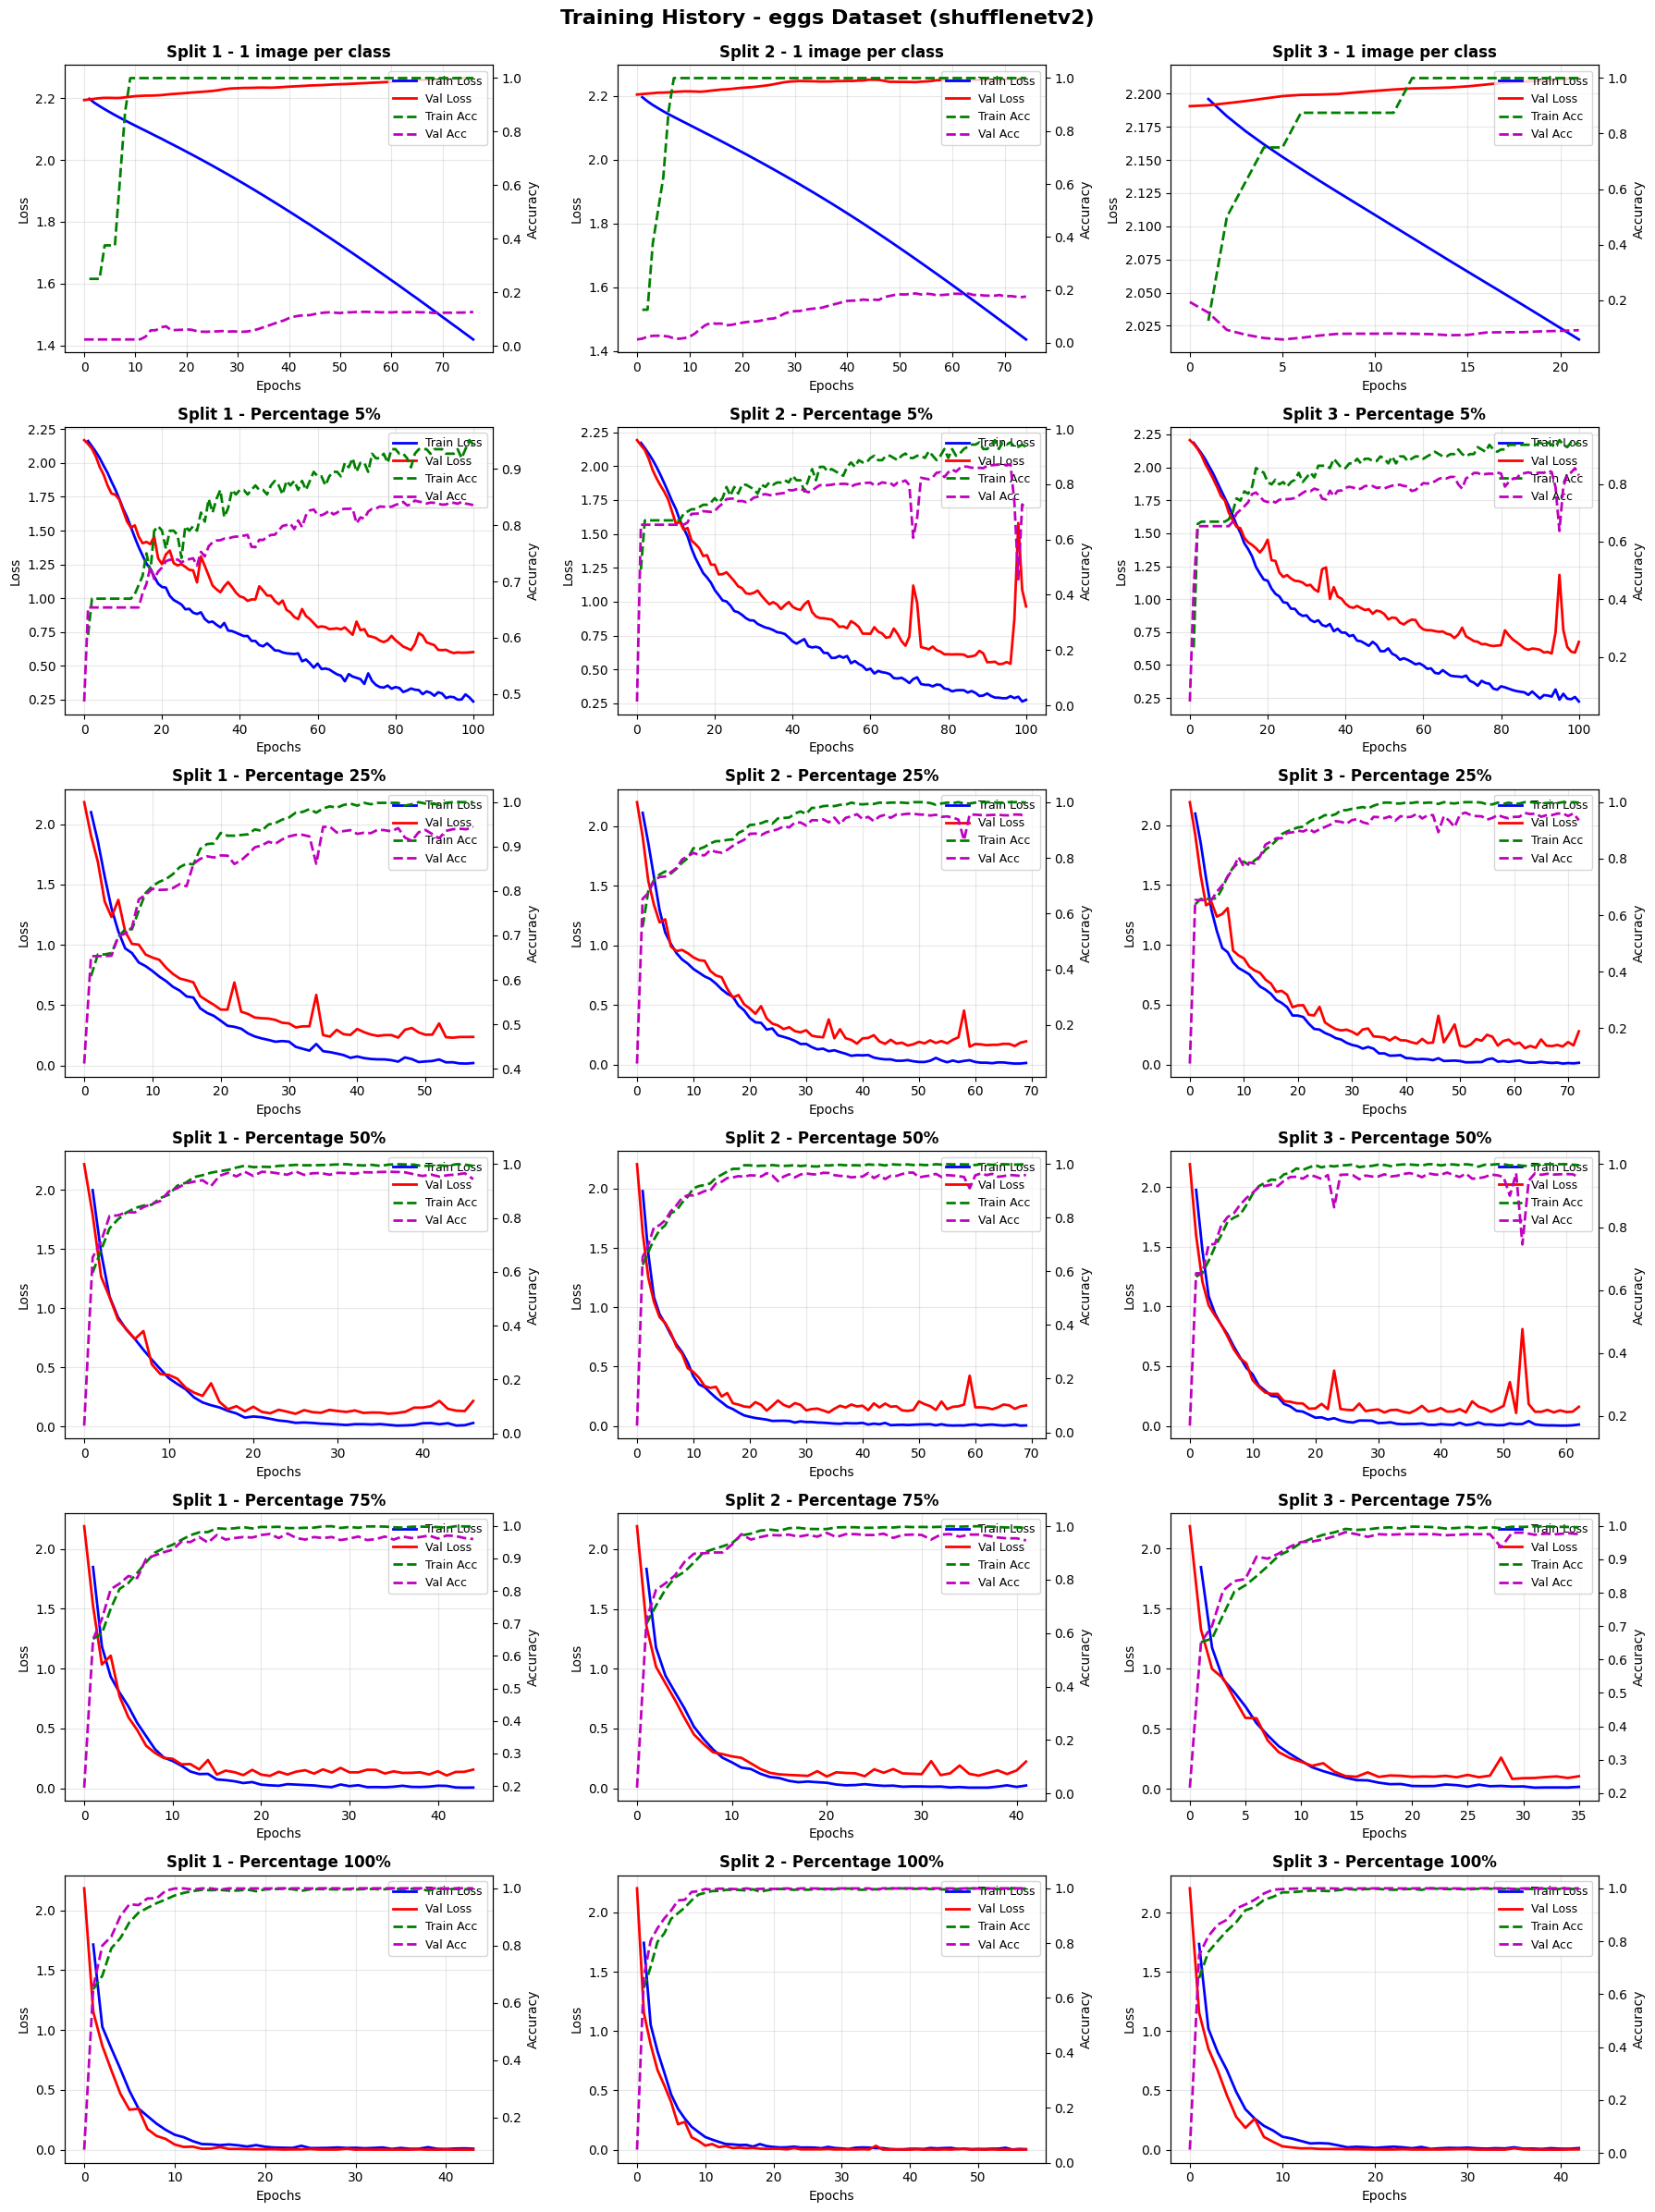

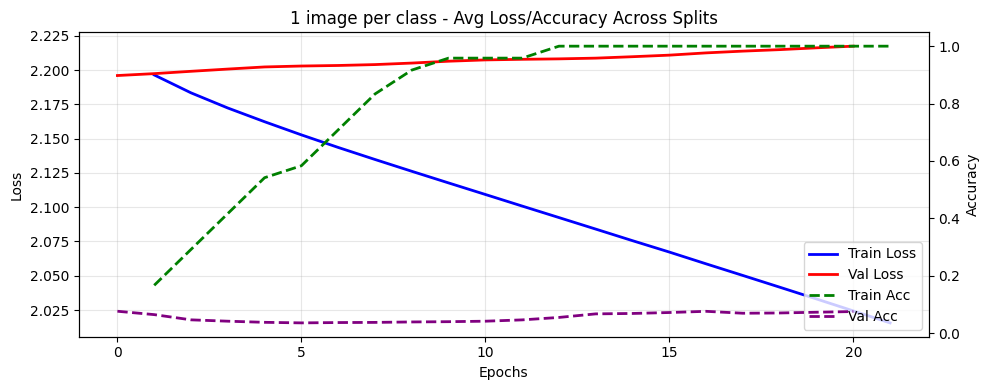

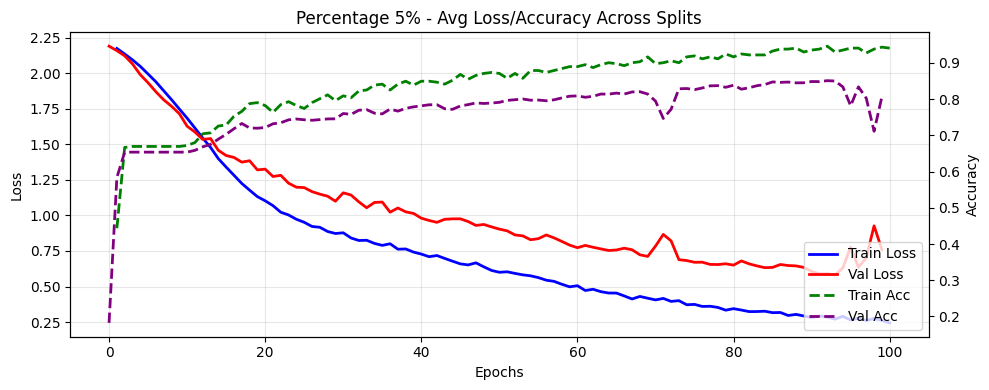

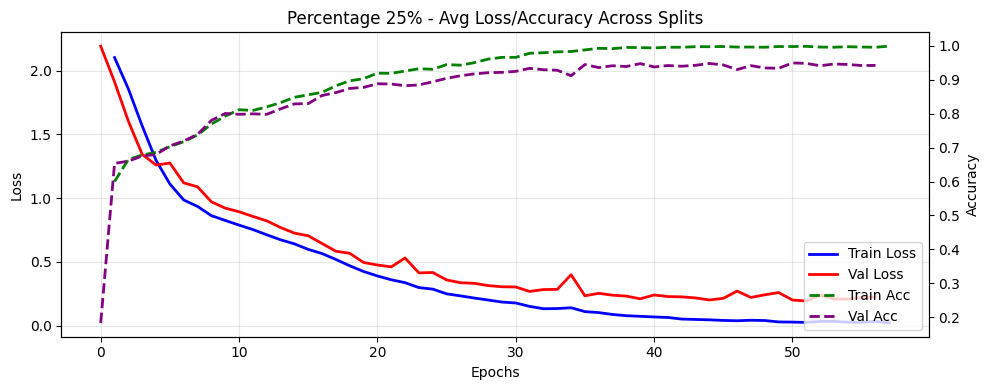

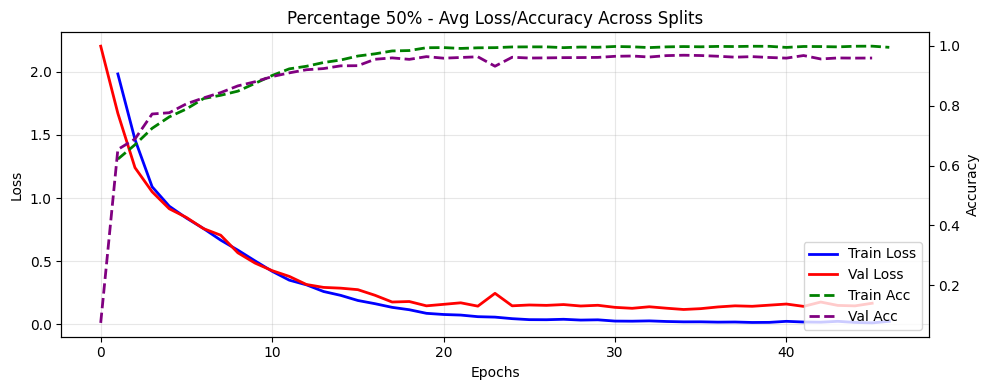

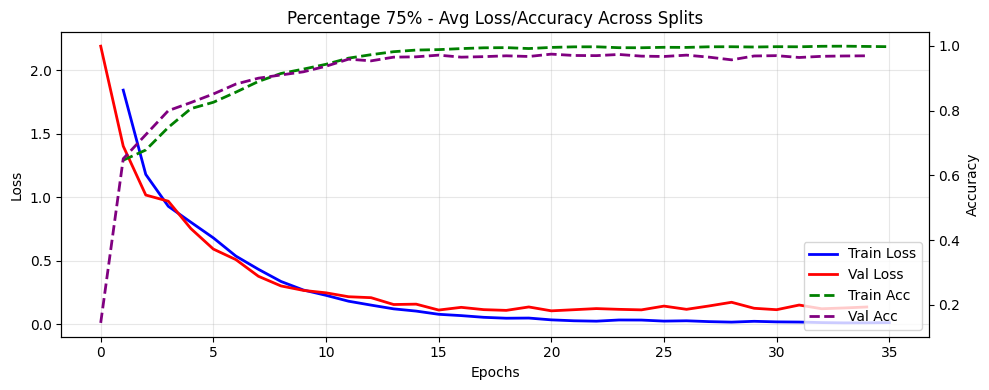

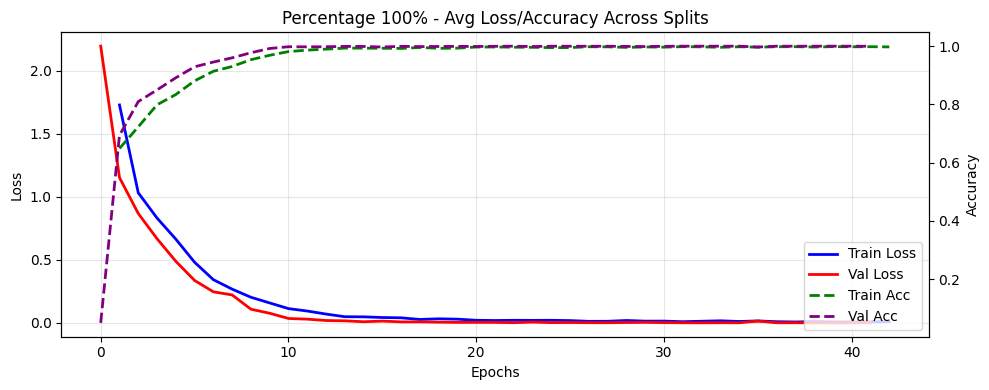

In [6]:
loss_and_accuracy_split(config, path, model_name, False)
loss_and_accuracy_aggregate(config, path, model_name, False)

In [7]:
results_test = evaluate_test_set(config, path, model_name, dataloaders)

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)
    
calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to shufflenetv2/eggs/shufflenetv2_aggregated_classification_report_eggs.txt


### Cistos

In [7]:
# Configuration for Cisto Dataset
CONFIG_CISTO = {
    'dataset_name': 'cistos',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 7,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_CISTO['dataset_name']
model_name = 'shufflenetv2'
path = f"{model_name}/{dataset_name}"
config = CONFIG_CISTO
dataloaders = {}

transforms_cistos = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = create_dataloaders(config=config, transforms=transforms_cistos)

model_pretrained, _, _, _ = create_model(description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config)

In [8]:
n_flops, n_params = count_flops(model_pretrained, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
# mostra o valor total
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: shufflenetv2 - Dataset: cistos
FLOPs: 133905176.0 FLOPs
Parameters: 1260779.0 


In [23]:
historic_train = train_loop(config, dataloaders, path, dataset_name, model_name)
        
# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)

Early stopping at epoch 21 for split 1 and percentage 1%


Early stopping at epoch 22 for split 2 and percentage 1%


Early stopping at epoch 21 for split 3 and percentage 1%


Early stopping at epoch 64 for split 1 and percentage 5%


Early stopping at epoch 58 for split 2 and percentage 5%


...

Early stopping at epoch 58 for split 2 and percentage 75%


Early stopping at epoch 72 for split 3 and percentage 75%


Early stopping at epoch 40 for split 1 and percentage 100%


Early stopping at epoch 38 for split 2 and percentage 100%


Early stopping at epoch 45 for split 3 and percentage 100%


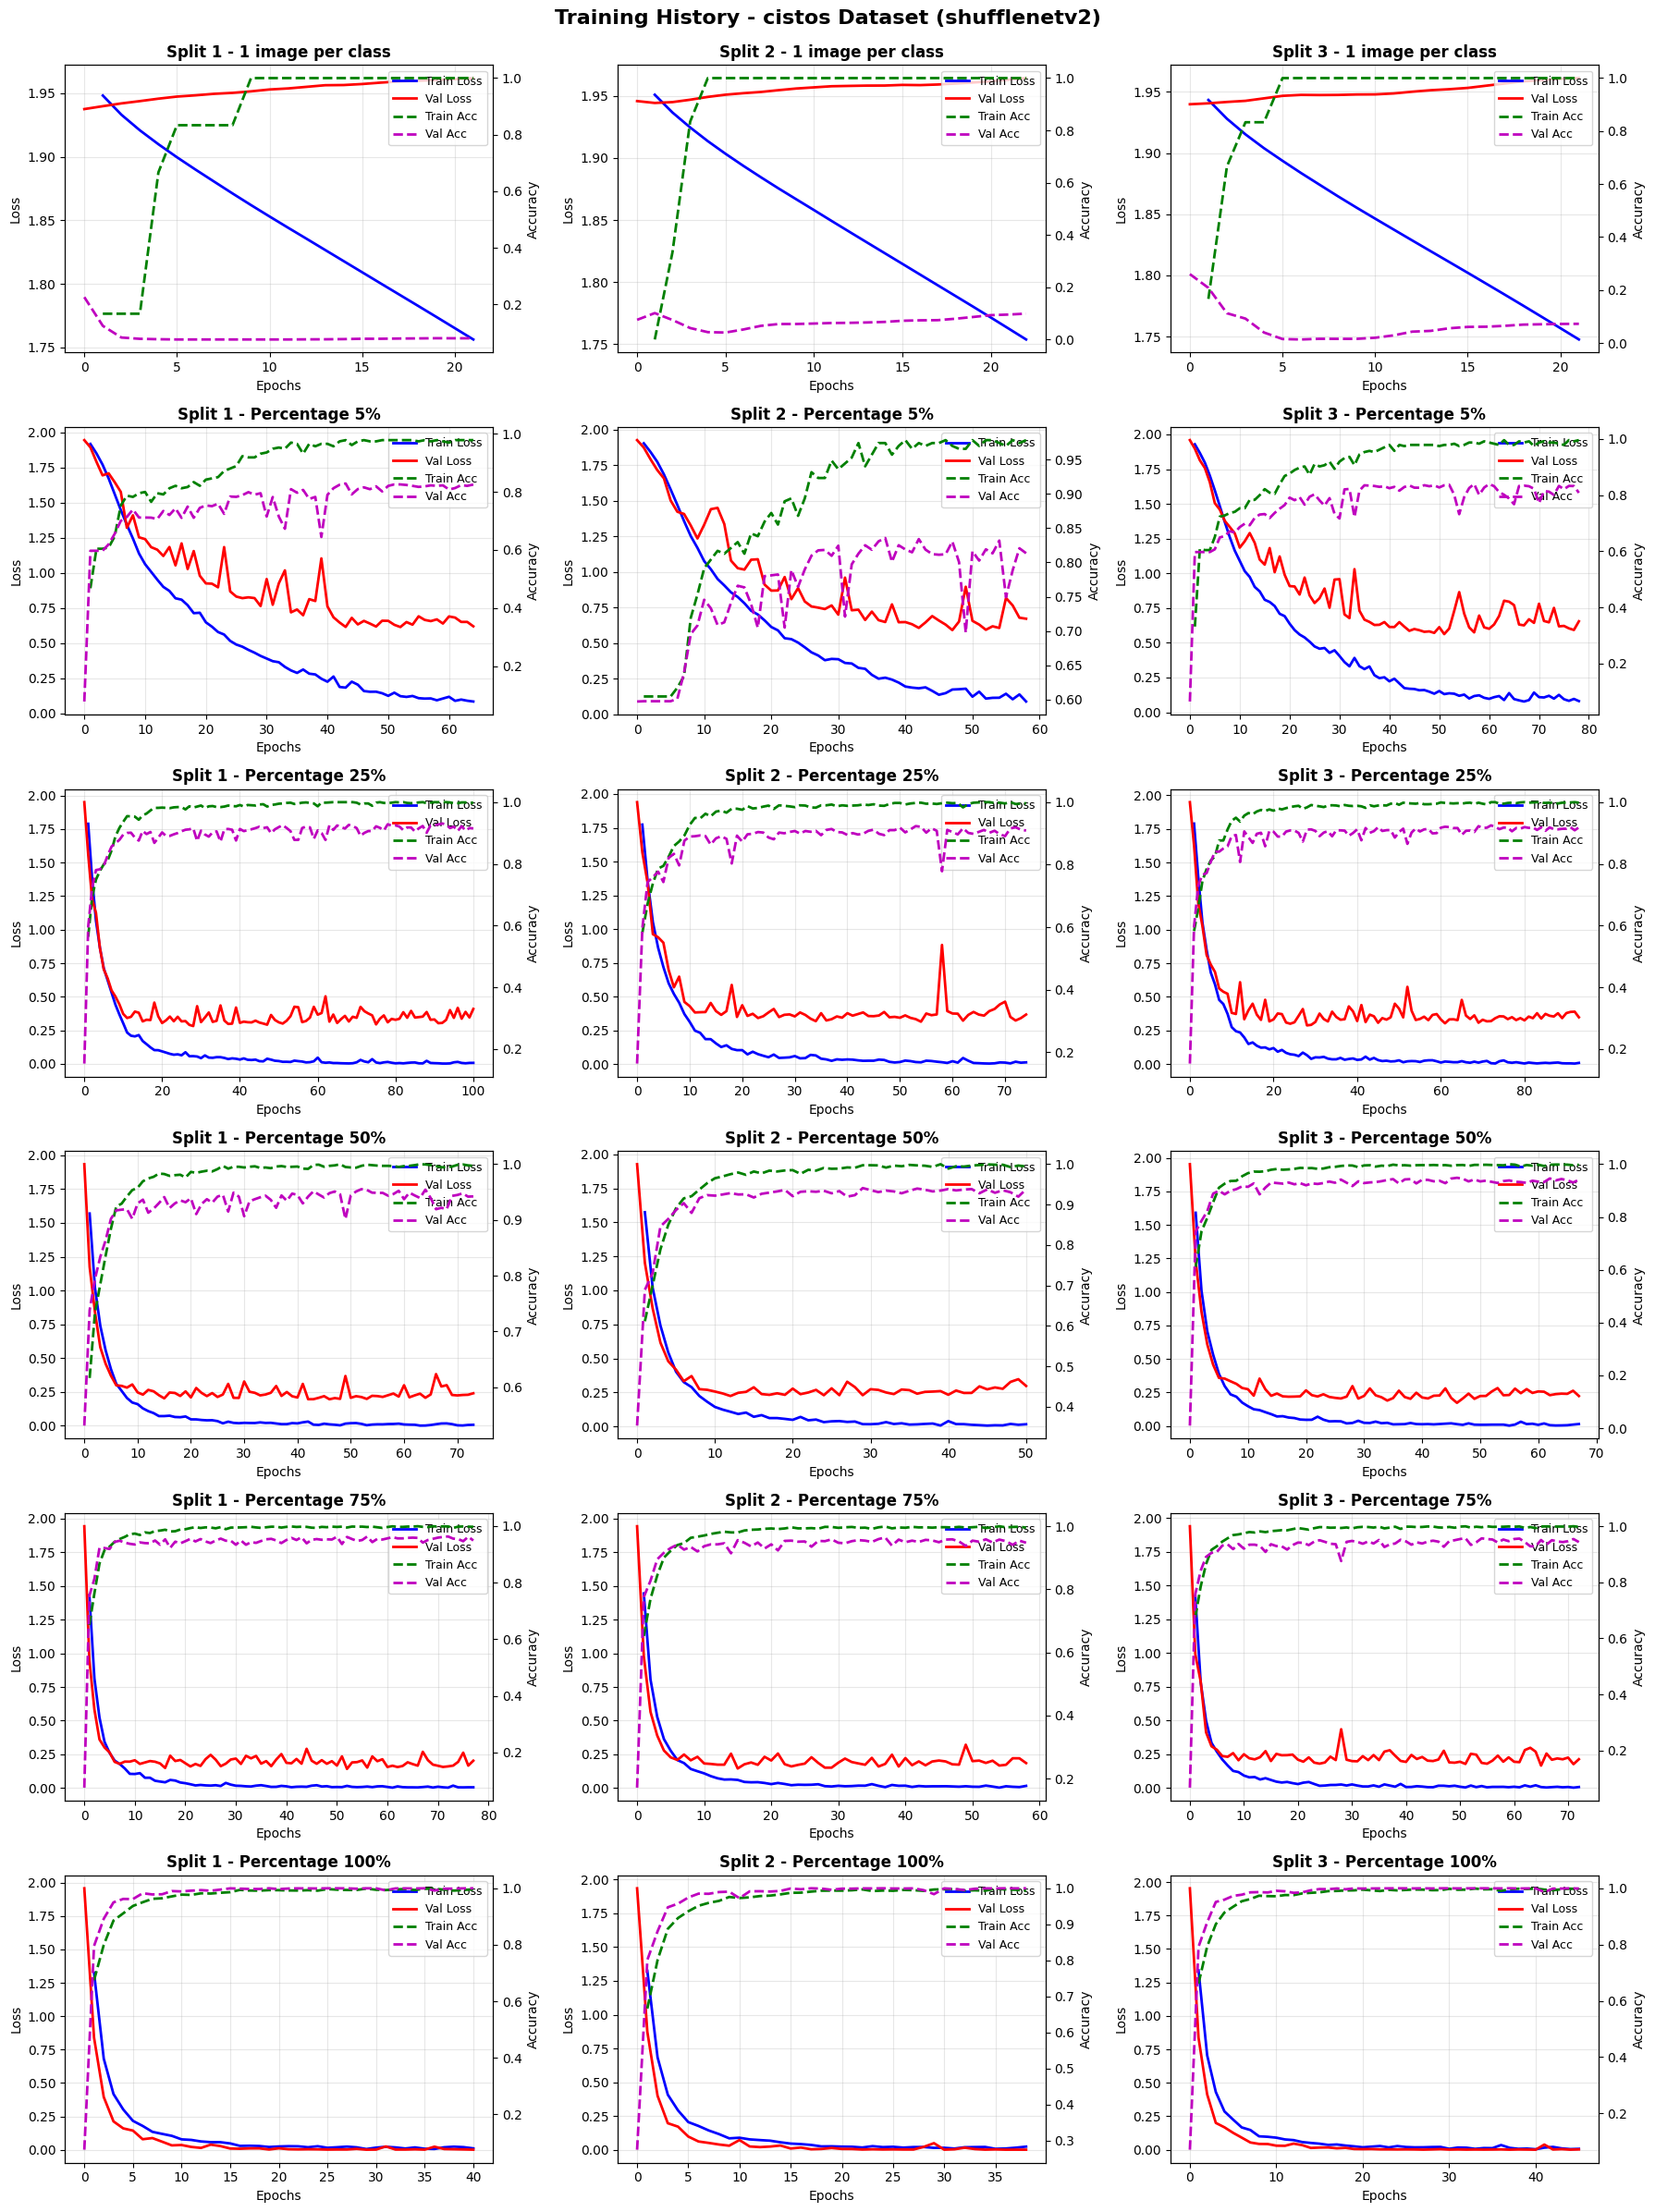

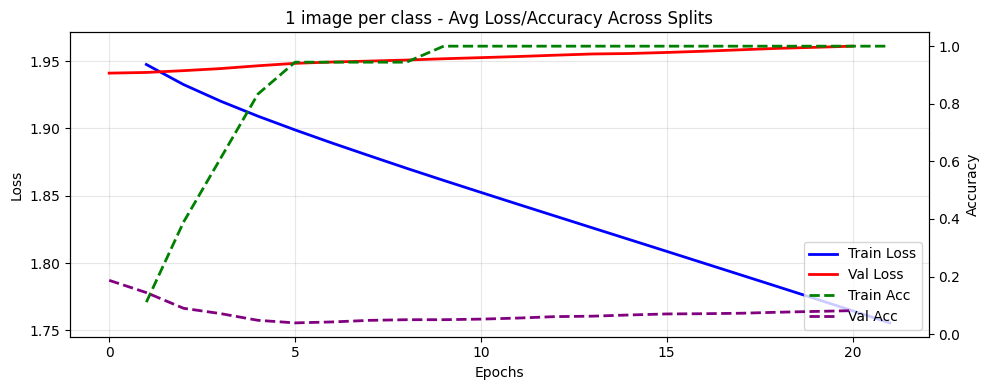

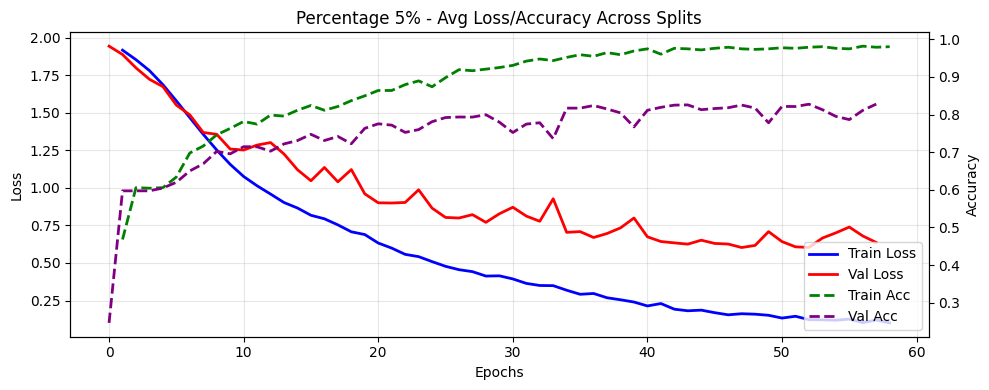

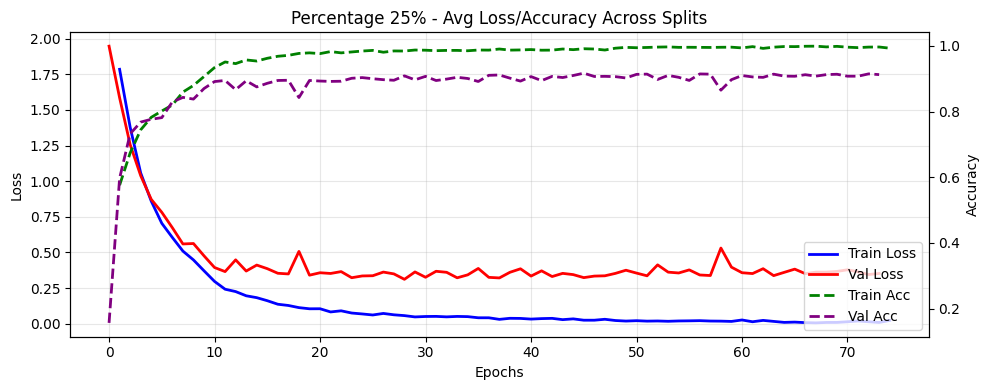

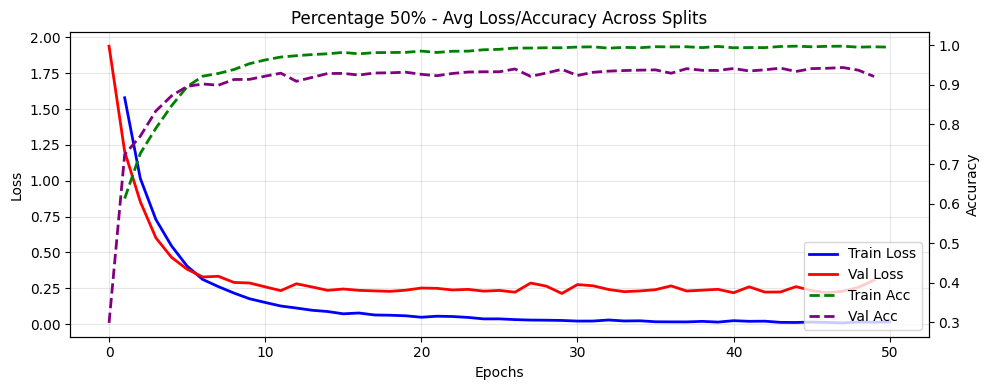

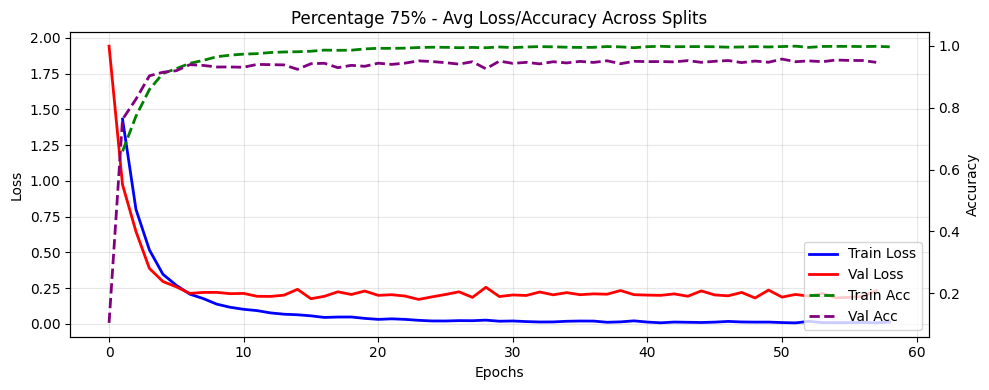

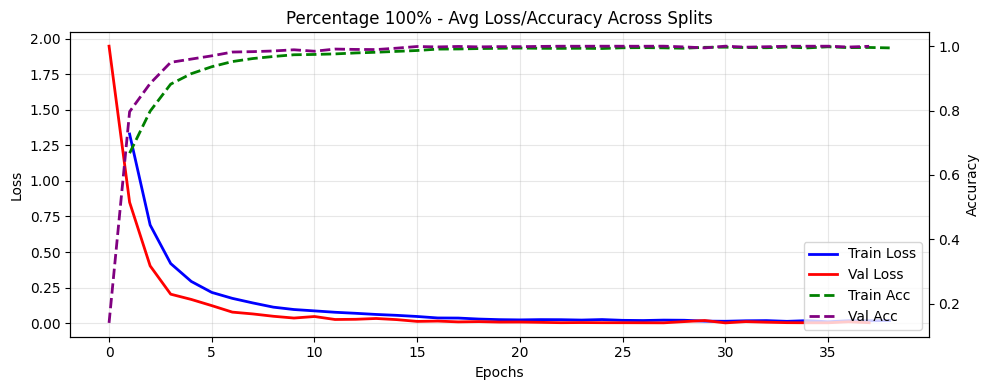

In [24]:
loss_and_accuracy_split(config, path, model_name, show_plot=False)
loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

In [25]:
results_test = evaluate_test_set(config, path, model_name, dataloaders)

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)
    
calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to shufflenetv2/cistos/shufflenetv2_aggregated_classification_report_cistos.txt


### Larvas

In [9]:
# Configuration for Larvae Dataset
CONFIG_LARVAE = {
    'dataset_name': 'larvae',
    'split': [1,2,3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 2,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_LARVAE['dataset_name']
model_name = 'shufflenetv2'
path = f"{model_name}/{dataset_name}"
config = CONFIG_LARVAE
dataloaders = {}

transforms_larvae = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = create_dataloaders(config=config, transforms=transforms_larvae)

model_pretrained, _, _, _ = create_model(description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config)

In [10]:
n_flops, n_params = count_flops(model_pretrained, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
# mostra o valor total
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: shufflenetv2 - Dataset: larvae
FLOPs: 133900056.0 FLOPs
Parameters: 1255654.0 


In [35]:
historic_train = train_loop(config, dataloaders, path, dataset_name, model_name)
        
# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)

Early stopping at epoch 21 for split 1 and percentage 1%


Early stopping at epoch 33 for split 2 and percentage 1%


Early stopping at epoch 57 for split 3 and percentage 1%


Early stopping at epoch 55 for split 1 and percentage 5%


Early stopping at epoch 42 for split 2 and percentage 5%


...

Early stopping at epoch 45 for split 2 and percentage 75%


Early stopping at epoch 29 for split 3 and percentage 75%


Early stopping at epoch 26 for split 1 and percentage 100%


Early stopping at epoch 28 for split 2 and percentage 100%


Early stopping at epoch 27 for split 3 and percentage 100%


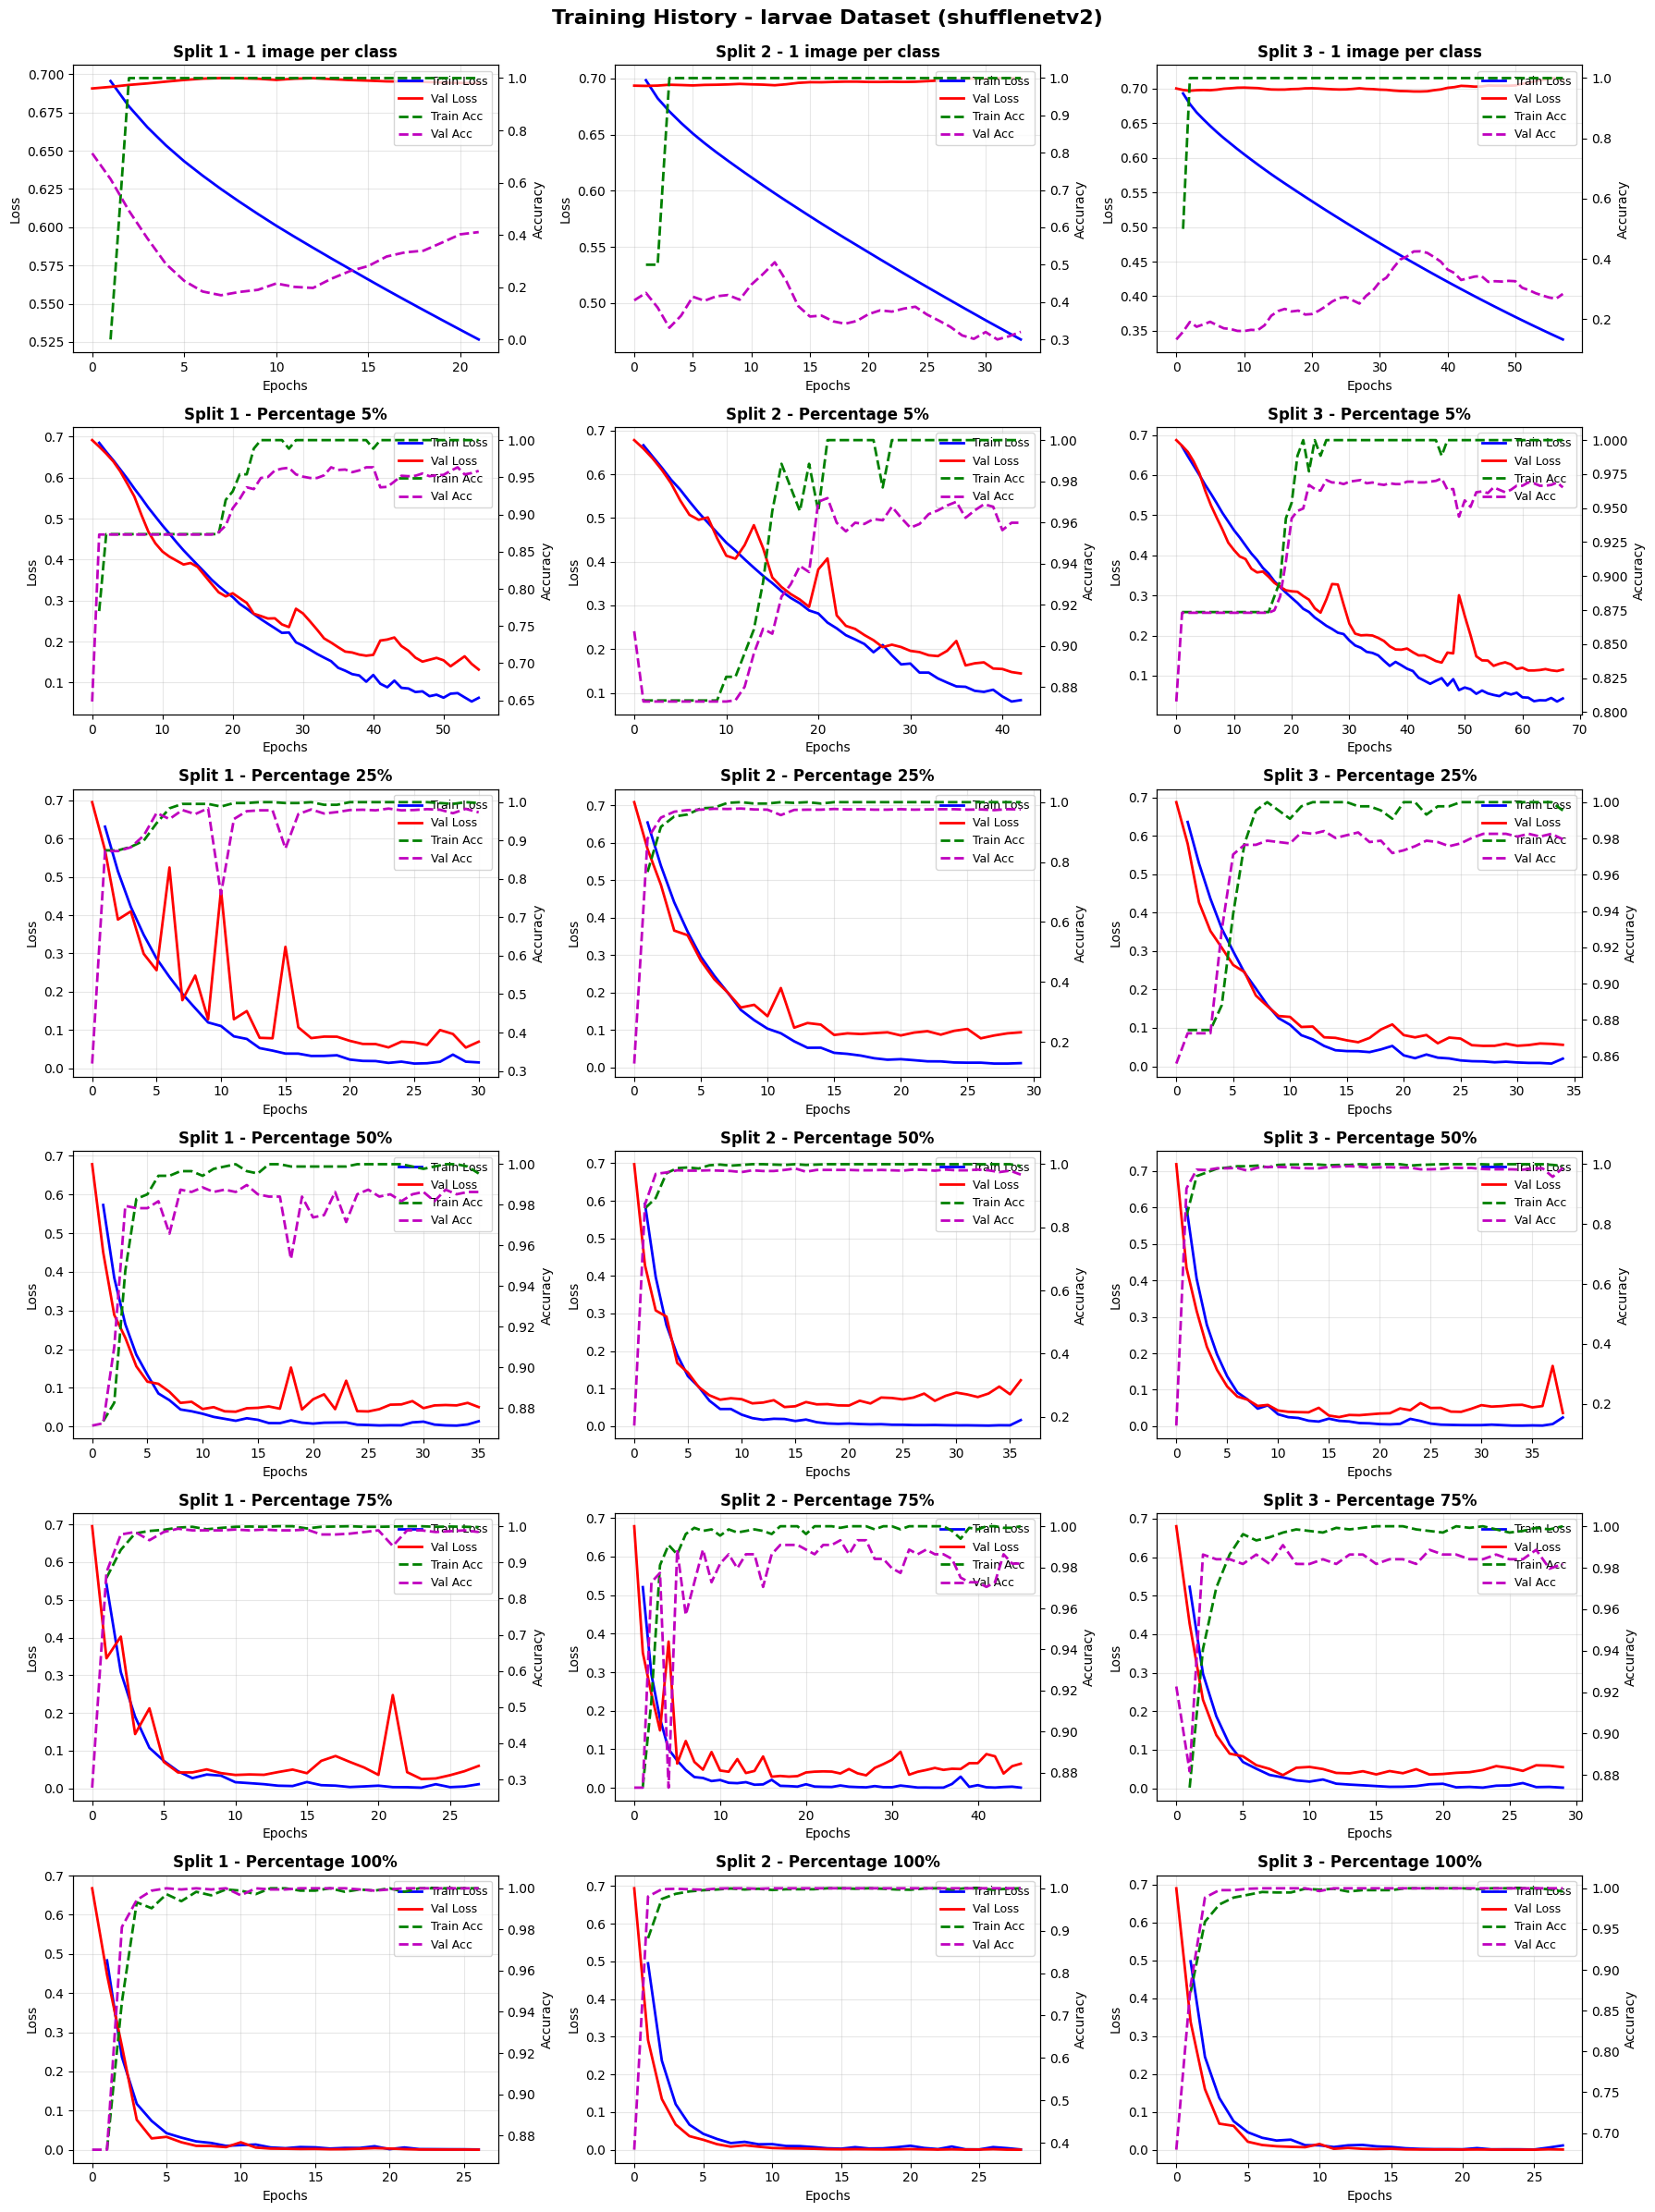

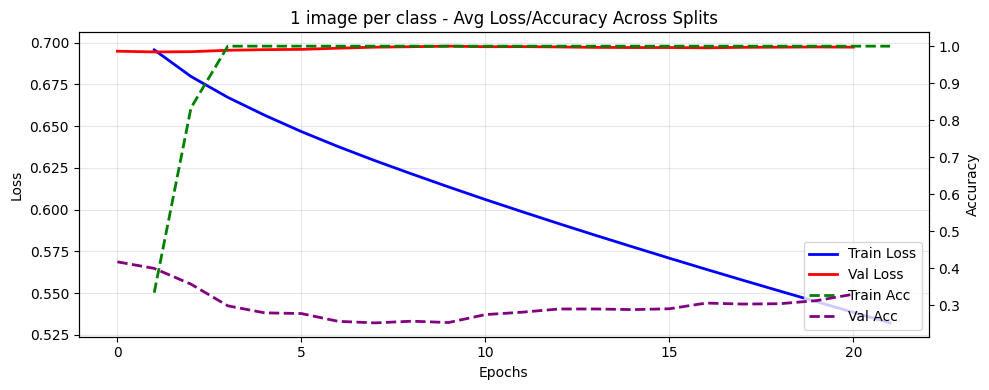

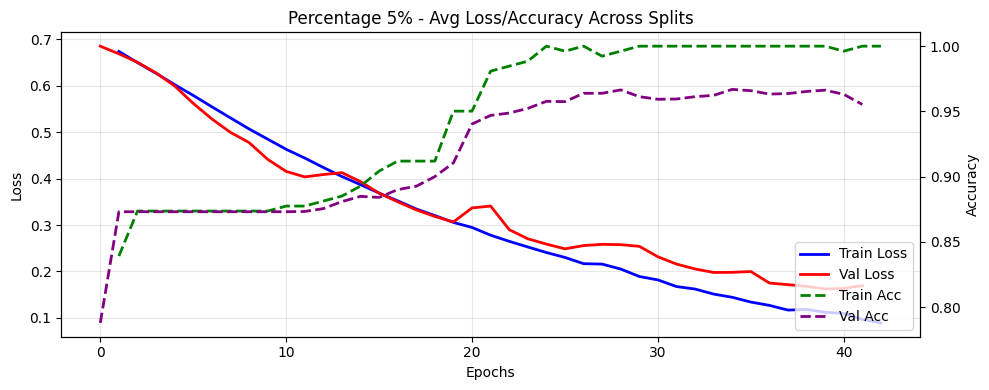

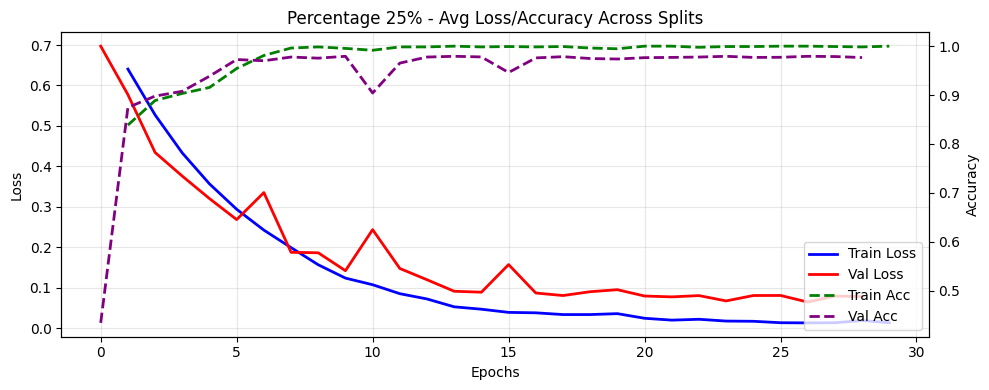

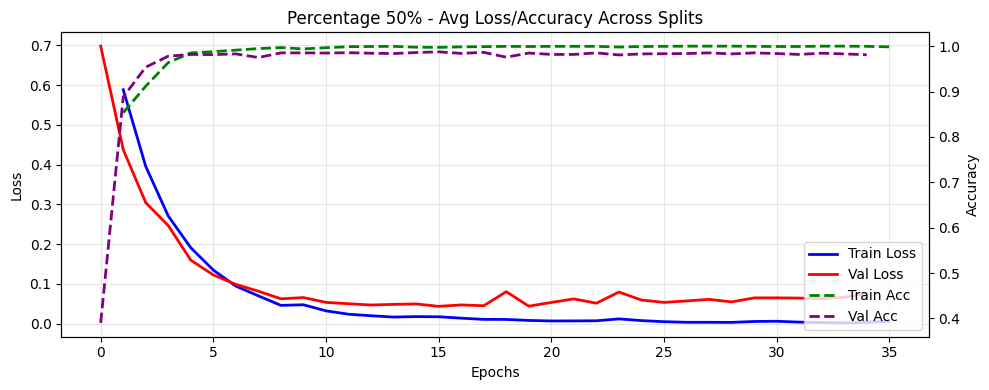

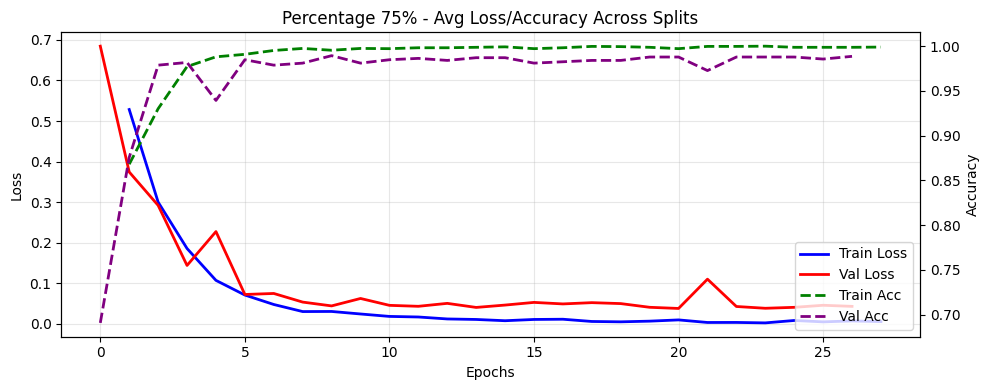

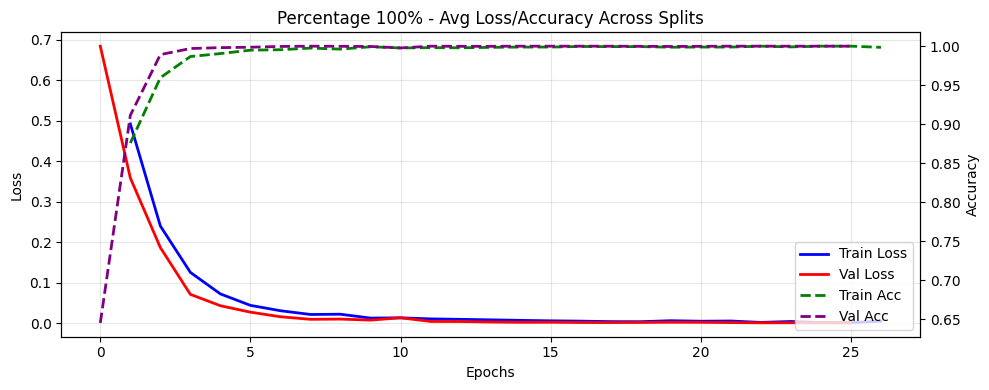

In [36]:
loss_and_accuracy_split(config, path, model_name, show_plot=False)
loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

In [37]:
results_test = evaluate_test_set(config, path, model_name, dataloaders)

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)
    
calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to shufflenetv2/larvae/shufflenetv2_aggregated_classification_report_larvae.txt
